# Add correctors upstream

In [1]:
%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
from pytao import Tao

## Add some correctors

In [3]:
def make_corrector(name, s):
    return f'{name}: hkicker, field_master=T, superimpose, ref=L1X, offset = {s}'

slist = np.linspace(10, 190, 10)

corrs = [make_corrector(f'XX_{i}', s) for i, s in enumerate(slist)]

open('my_correctors.bmad', 'w').write('\n'.join(corrs))

slist

array([ 10.,  30.,  50.,  70.,  90., 110., 130., 150., 170., 190.])

In [4]:
# Start tao
tao = Tao('-init $LCLS_LATTICE/bmad/examples/ltuh_orbit_correction/tao.init -slice L1X:END')

In [5]:
%%tao
veto var *
veto dat *
use dat orbit.x
use var mykick.x

-------------------------
Tao> veto var *
  xcor[1:18]                                     Using:
  mykick.x[1:10]                                 Using:
  ycor[1:158]                                    Using:
-------------------------
Tao> veto dat *
  aperture.p[0:15]                               Using:
  aperture.n[0:15]                               Using:
  orbit.x[1:123]                                 Using:
  orbit.y[1:0]                                   Using:
  orbit.profx[1:0]                               Using:
  orbit.profy[1:0]                               Using:
  orbit.e[1:0]                                   Using:
  loss[1:1]                                      Using:
-------------------------
Tao> use dat orbit.x
  orbit.x[1:123]                                 Using: 1:123
  orbit.y[1:0]                                   Using:
  orbit.profx[1:0]                               Using:
  orbit.profy[1:0]                               Using:
  orbit.e[1:0]         

In [6]:
%%time
rmat =tao.derivative()[1]
rmat.shape

CPU times: user 177 ms, sys: 21.9 ms, total: 199 ms
Wall time: 201 ms


(122, 10)

Text(0.5, 1.0, 'Corrector-BPM response')

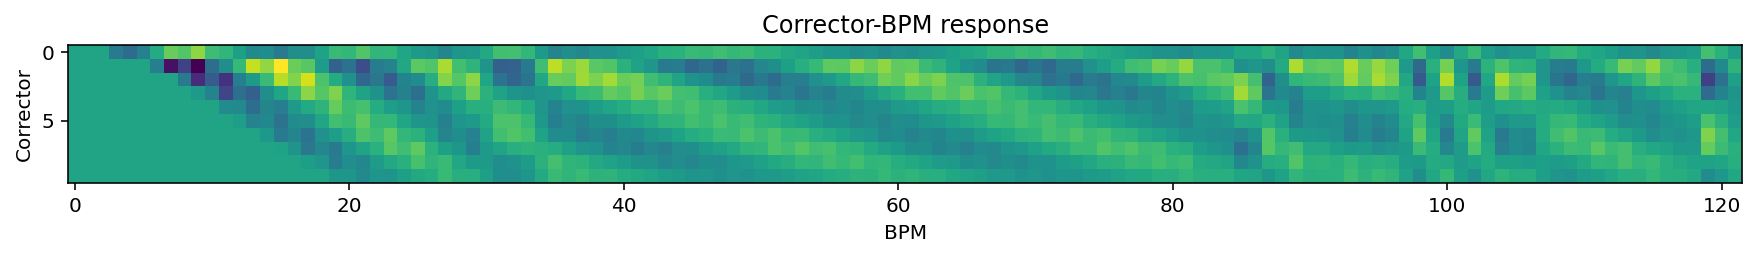

In [7]:
fig, ax = plt.subplots(figsize=(15,15))
ax.imshow(rmat.T)
ax.set_xlabel('BPM')
ax.set_ylabel('Corrector')
ax.set_title('Corrector-BPM response')